# Day 4 — Retrieval Augmented Generation (RAG)
### *Grounded generation with **real embeddings**: when does retrieval help, and when does it still fail?*

<a href="https://colab.research.google.com/github/Tulane-CMPS-1010-AI-Systems/course-materials/blob/main/lectures/04-rag_lecture.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

---

## Learning objectives (by the end of this notebook, you can…)
- **Explain** the RAG pipeline and identify where grounding can fail (retrieval, packing, generation).
- **Choose chunking + retrieval settings** (chunk size, overlap, top-*k*) and predict how they affect evidence quality and token cost.
- **Compute and interpret Recall@k** (and why it’s not enough without context limits).
- **Define and estimate hallucination rate** as “unsupported claims per answer.”
- **Run small experiments** to see how chunk size and top-*k* affect Recall@k and hallucination rate (this week’s lab focus).
- **Make engineering tradeoffs** between quality, groundedness, latency, and cost.

> **Assumption:** you already know what embeddings are and why cosine similarity works.  
> Here we focus on *system design + evaluation* for RAG.


In [1]:
# @title 🔧 Setup (Run this first)
!git clone --depth 1 -q https://github.com/Tulane-CMPS-1010-AI-Systems/course-materials.git
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.append('./course-materials')
from course_utils import lab5_setup, show_mermaid
lab5_setup()

🔧 Setting up your environment...
  → Installing core packages...
installing mermaid-python
  → Setting random seed for reproducible results...
  → Checking API key...
🔑 Enter your OpenAI API key.
   (It will only be stored in this Colab runtime - it's safe!)
   Get your key from: https://platform.openai.com/api-keys
OpenAI API key: ··········
✅ API key set.
  → Adding course files to path...
✅ Setup complete!
✅ lab5_setup complete — ready.


---

# RAG as a pipeline: grounding, chunking, top-*k*, context limits

## Quick “last lab” connection (start-of-class)
In the first ~10 minutes, we’ll do a **Lab Review**:
- a few students present what they tried,
- we compare what improved results,
- we name the tradeoff (latency, tokens, complexity).

### Discussion prompt
> **What knob did you turn last week that improved results — and what did it cost you?**

Hold onto that thought: RAG is basically a set of knobs, but now they live in a pipeline.

---

## **Why can AI be brilliant… and then confidently wrong?**
Two stories that can both be true:

### ✅ Inspiring success
A model answers:
> “Interns may join on-call after onboarding and manager approval.”  
…and it **quotes the exact policy lines**.

### ❌ Painful failure
A model answers:
> “Interns must join on-call after 30 days (Policy 12.7).”  
…but **Policy 12.7 doesn’t exist**.

### Guiding questions
- **Where does “truth” come from** in a RAG system: the model’s memory, or retrieved evidence?
- If retrieval is perfect, **can generation still hallucinate**?
- If generation is perfect, **can retrieval still fail**?

RAG is an attempt to make language models behave more like:
> “Show me your work.”


## Retrieval Augmented Generation

**Idea:** Perform a document search to find information relevant to query, then pass to a prompt to serve as context for the generated answer.


<img width="60%" src="https://github.com/tulane-cmps6730/main/blob/main/lec/chat/figs/rag1.png?raw=true">

[source](https://web.stanford.edu/class/cs329t/)

**Key steps:**

1. Break documents into chunks
2. Vectorize chunks
3. Vectorize query
4. Retrieve chunks similar to the query
5. Create LLM Prompt




Why?

<br><br><br>

- Don't want to include an entire document as part of the prompt (time + relevance).

Many options here:
- Break into sentences (e.g., see [NLTK](https://www.nltk.org/api/nltk.tokenize.sent_tokenize.html))
- Fixed window of N words or characters.
- Overlapping vs non-overlapping windows (**why?**)






In [ ]:
# @title Visual: RAG pipeline diagram
mermaid = r'''
flowchart LR
    U["User Question"] --> QP["Query Processing\nrewrite | expand | filters"]
    QP --> R["Retriever\nvector | hybrid search"]
    R --> C["Candidates\ntop-k chunks"]
    C --> RR["Reranker (optional)"]
    RR --> P["Context Builder\npack within limits"]
    P --> G["Generator (LLM)"]
    G --> O["Answer + citations"]
    O --> M["Monitoring & Eval\nrecall@k, hallucination rate"]
    M --> QP'''
show_mermaid(mermaid)


## 📁 Working with Real Data Sources




Most RAG systems need to work with **real documents** from your domain. Here are common patterns for loading data:

### Common Data Sources
- **Text files** (.txt, .md) - Easiest to start with
- **Web pages** (HTML, scraping) - Common for public information
- **PDFs** (requires special libraries) - Optional, more complex
- **Structured data** (CSV, JSON) - For tabular or structured information

### Preprocessing Steps
1. **Text cleaning**: Remove extra whitespace, normalize encoding
2. **Document splitting**: Split large files into logical documents
3. **Metadata extraction**: Keep track of source, date, etc.
4. **Filtering**: Remove empty or very short documents

### Example: Loading from Google Drive

**Most students will store project data in Google Drive.** Here's the pattern:

```python
from google.colab import drive
drive.mount('/content/drive')

# Navigate to your folder
from pathlib import Path
drive_path = Path("/content/drive/My Drive/your_project/data/")

# Load files
documents = []
for file_path in drive_path.glob("*.txt"):
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read().strip()
        if len(text) > 50:  # Skip very short files
            documents.append(text)
```

**Tips:**
- Organize files in a folder like "AI_Project/documents/"
- First time: You'll authorize Colab to access Drive (click link, sign in, copy code)
- Path format: Always use `/content/drive/My Drive/` as base
- File types: Works with .txt, .md, .csv, etc.

### Example: Loading from URLs

For web-based data:

```python
import requests
from bs4 import BeautifulSoup

def load_from_url(url):
    """Fetch and extract text from a web page."""
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    # Remove script and style elements
    for script in soup(["script", "style"]):
        script.decompose()
    text = soup.get_text()
    # Clean up whitespace
    lines = (line.strip() for line in text.splitlines())
    chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
    text = ' '.join(chunk for chunk in chunks if chunk)
    return text
```

### Example: Loading Multiple Text Files

```python
from pathlib import Path

def load_text_files(directory):
    """Load all .txt files from a directory."""
    documents = []
    for file_path in Path(directory).glob("*.txt"):
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read().strip()
            if len(text) > 50:  # Skip very short files
                documents.append(text)
    return documents
```

**For your project:** You'll use these patterns to load your own data (campus docs, lecture notes, city data, etc.) instead of using the tiny sample corpus.

---


## **What does “grounding” mean in RAG?**
We’ll use a practical definition:

> An answer is **grounded** if its key claims are **supported by the retrieved context**.

That means grounding can fail in at least three places:
1) **Missed retrieval**: the right evidence exists, but we didn’t retrieve it.
2) **Context packing failure**: we retrieved it, but it didn’t fit (or got buried).
3) **Ungrounded generation**: the evidence is present, but the model ignores it or adds unsupported claims.

We’ll build a small RAG sandbox to *see* these failure modes.

---

# Part A — Build a tiny RAG sandbox (minimal code)
We’ll use a tiny document set (policies + FAQ + runbook).  
Then we’ll:
- chunk documents,
- embed chunks using `get_text_embedding`,
- retrieve top-*k* chunks with cosine similarity,
- pack them into a context budget,
- and measure a toy “hallucination rate.”

> In real RAG, you’d also add reranking, metadata filters, and permission checks. We’ll keep this minimal today.


In [ ]:
# @title Tiny corpus (4 documents)
corpus_docs = [
    {
        "doc_id": "policy_access",
        "title": "Access Control Policy",
        "text": '''
All employees must use single sign-on (SSO). Interns are granted access to internal tools
including Jira, Confluence, and GitHub Enterprise within the first week.

Interns may NOT access customer production data. Requests for elevated access require
manager approval and a security review. Access to incident response channels is read-only
unless the intern is explicitly added to an on-call rotation.
'''.strip(),
        "meta": {"type": "policy", "updated": "2025-09-01"}
    },
    {
        "doc_id": "policy_oncall",
        "title": "On-Call Rotation Policy",
        "text": '''
The on-call rotation is required for full-time engineers and optional for interns.
Interns may join on-call only after completing onboarding, passing the incident response
training quiz, and receiving manager approval. Interns should start with shadow shifts.
'''.strip(),
        "meta": {"type": "policy", "updated": "2025-11-15"}
    },
    {
        "doc_id": "faq_security",
        "title": "Security FAQ",
        "text": '''
Q: Can interns access production?
A: No. Interns do not get production access unless the security team grants an exception.

Q: What is required for elevated access?
A: Manager approval, least-privilege review, and time-bounded access.
'''.strip(),
        "meta": {"type": "faq", "updated": "2024-06-20"}
    },
    {
        "doc_id": "runbook_incidents",
        "title": "Incident Response Runbook",
        "text": '''
Incident responders should: (1) acknowledge the page, (2) assess severity, (3) mitigate,
(4) communicate updates in the incident channel every 15 minutes, and (5) write a postmortem.

Shadow shifts are recommended for first-time responders.
'''.strip(),
        "meta": {"type": "runbook", "updated": "2025-05-02"}
    }
]

confusers = [
    {
        "doc_id": "confuser_access_faq",
        "title": "Access FAQ (Unofficial / Team Notes)",
        "text": """
Q: What is required for elevated access?
A: Fill out the access request form and wait for automated approval.

Q: Do interns get production access?
A: Yes, for debugging, interns can request temporary production access.
""".strip(),
        "meta": {"type": "notes", "updated": "2025-10-20"}
    },
    {
        "doc_id": "confuser_oncall_faq",
        "title": "On-Call FAQ (Unofficial / Team Notes)",
        "text": """
Q: Can interns join the on-call rotation?
A: Interns are required to join on-call after 30 days.

Q: What are incident responders supposed to do during an incident?
A: Acknowledge the page and escalate to the on-call lead.
""".strip(),
        "meta": {"type": "notes", "updated": "2025-10-21"}
    },
]

corpus_docs = corpus_docs + confusers
# print("New total docs:", len(corpus_docs))
# print("Added:", [d["doc_id"] for d in distractors])


print(f"Loaded {len(corpus_docs)} docs:", [d["doc_id"] for d in corpus_docs])


In [ ]:
print(corpus_docs[0]['text'])

---

## **How should we chunk documents for retrieval?**
Chunking is the first “RAG knob.”

### Chunk size tradeoff
- **Small chunks**: more precise matching, but can lose context (“what does *this* refer to?”)
- **Large chunks**: more context, but less precise and can waste context window space

We’ll chunk by words (easy to read). In real systems, you’d chunk by tokens and use structure (headers, sections, tables).


In [ ]:
# @title Chunking (minimal utilities)
import re

def words(text):
    return re.findall(r"[A-Za-z0-9']+", text.lower())

def chunk_text(text, chunk_size=80, overlap=20):
    w = words(text)
    chunks = []
    start = 0
    while start < len(w):
        end = min(start + chunk_size, len(w))
        chunks.append(" ".join(w[start:end]))
        if end == len(w):
            break
        start = end - overlap
    return chunks

def make_chunks(docs, chunk_size=80, overlap=20):
    chunks = []
    for d in docs:
        for i, ch in enumerate(chunk_text(d["text"], chunk_size, overlap)):
            chunks.append({
                "chunk_id": f"{d['doc_id']}::c{i}",
                "doc_id": d["doc_id"],
                "title": d["title"],
                "text": ch,
                "meta": d["meta"]
            })
    return chunks

chunks = make_chunks(corpus_docs, chunk_size=70, overlap=15)
print("Total chunks:", len(chunks))
print("Example:", chunks[0]["chunk_id"], "|", chunks[0]["text"][:140], "…")


In [ ]:
chunks[0]

### Reflection
> What do you think happens if we make chunks extremely small (like 15 words)?  
> Which questions become harder to answer?

---

## **Retrieval with real embeddings**
We’ll **embed** each chunk with `get_text_embedding(text)` and retrieve by a **similarity** score called cosine similarity.

We’ll keep retrieval code minimal:
- embed all chunks once
- normalize vectors
- define similarity: dot product = cosine similarity


In [ ]:
# @title Build an embedding index (minimal)

from course_utils import get_text_embedding

def normalize(v):
    v = np.array(v, dtype=np.float32)
    return v / (np.linalg.norm(v) + 1e-12)

def build_index(chunks):
    X = np.vstack([normalize(get_text_embedding(c["text"])) for c in chunks])
    return X

def search(query, chunks, X, top_k=5):
    q = normalize(get_text_embedding(query))
    sims = X @ q
    idx = np.argsort(-sims)[:top_k]
    return [(float(sims[i]), chunks[int(i)]) for i in idx]

X = build_index(chunks)

q = "Can interns join the on-call rotation?"
results = search(q, chunks, X, top_k=5)
for s, c in results:
    print(f"{s:0.3f} | {c['chunk_id']} | {c['title']} | {c['text']}")


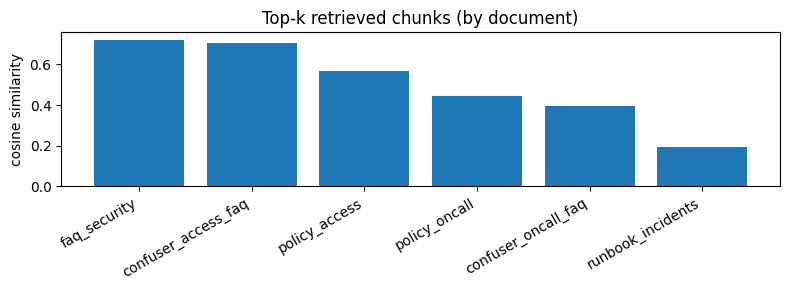

In [7]:
# @title Visualize top-k similarity scores
q = "Do interns get production access?"
results = search(q, chunks, X, top_k=8)

scores = [s for s, _ in results]
labels = [c["chunk_id"].split("::")[0] for _, c in results]

plt.figure(figsize=(8,3))
plt.bar(range(len(scores)), scores)
plt.xticks(range(len(scores)), labels, rotation=30, ha="right")
plt.ylabel("cosine similarity")
plt.title("Top-k retrieved chunks (by document)")
plt.tight_layout()
plt.show()


### Reflection
> If retrieval returns a chunk from the wrong document, what might be happening?
- Query is ambiguous?
- Chunk is missing context?
- Corpus has similar language in multiple places?
- Need metadata filters (date, type, permissions)?

---

## **Context limits turn retrieval into a packing problem**
Even if you retrieve 20 chunks, a model might only fit 3–8 chunks in context (depending on window size and chunk length).

So we need a simple context builder:
- include chunks in rank order
- stop when we hit a budget

We’ll use a rough “word budget” as a stand-in for tokens.


In [ ]:
# @title Context builder (minimal)
def pack_context(results, max_words=220):
    used = 0
    parts = []
    for score, c in results:
        header = f"[source={c['chunk_id']} updated={c['meta']['updated']}] "
        block = header + c["text"]
        n = len(words(block))
        if used + n > max_words:
            break
        parts.append(block)
        used += n
    return "\n\n".join(parts), used

q = "Can interns join the on-call rotation?"
results = search(q, chunks, X, top_k=10)
ctx, used = pack_context(results, max_words=180)
print("Context words used:", used)
print(ctx[:800], "…")


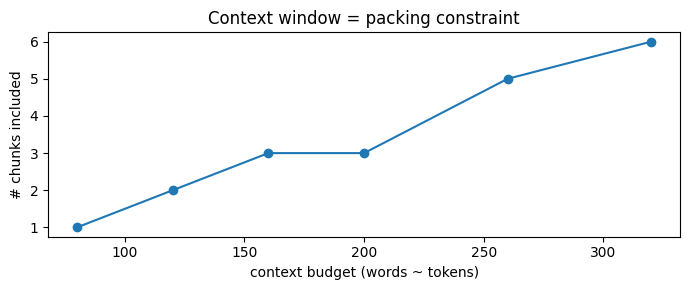

In [9]:
# @title Visual: how many chunks fit as budget increases?
q = "What are incident responders supposed to do during an incident?"
results = search(q, chunks, X, top_k=12)

budgets = [80, 120, 160, 200, 260, 320]
num_chunks = []
for b in budgets:
    ctx, _ = pack_context(results, max_words=b)
    num_chunks.append(ctx.count("[source="))

plt.figure(figsize=(7,3))
plt.plot(budgets, num_chunks, marker="o")
plt.xlabel("context budget (words ~ tokens)")
plt.ylabel("# chunks included")
plt.title("Context window = packing constraint")
plt.tight_layout()
plt.show()


### Reflection
> If we increase `top_k` but keep the context budget fixed, what changes?  
> (Hint: the model may see *the same number of chunks* — just different ones.)

---

# Part B — A tiny “hallucination rate” simulator
In the lab, you’ll measure hallucination rate more carefully (with a rubric or a simple judge).  
For today, we’ll build an **illustrative** (not production-grade) version.

Idea:
- we produce a short answer from context,
- sometimes we add a fake, confident sentence,
- then we estimate hallucination rate as “unsupported sentences / total sentences.”

This helps us reason about what settings might increase or reduce hallucinations.


---

## 📈 Scaling RAG to Larger Datasets

As your corpus grows, you need to think about efficiency.

### When is a Dataset "Large"?

- **Small**: < 100 documents, < 10,000 chunks → Process everything in memory
- **Medium**: 100-1000 documents, 10,000-100,000 chunks → Still manageable in Colab
- **Large**: > 1000 documents, > 100,000 chunks → Need optimization

### Simple Optimizations

**1. Cache embeddings**
- Don't recompute embeddings every time
- Save embeddings to a file and reload

```python
import pickle

# Save embeddings to Google Drive
with open('/content/drive/My Drive/AI_Project/embeddings.pkl', 'wb') as f:
    pickle.dump(embeddings, f)

# Load embeddings (much faster!)
with open('/content/drive/My Drive/AI_Project/embeddings.pkl', 'rb') as f:
    embeddings = pickle.load(f)
```

**2. Process in batches**
- For very large datasets, process documents in batches
- Update embeddings incrementally

**3. Filter before embedding**
- Remove very short or irrelevant documents early
- Saves computation time and API costs

### Project Guidance

For your project:
- **Start small** (10-50 documents)
- **Test** that your pipeline works
- **Then scale up** gradually
- **Monitor costs** (embedding API calls cost money!)

**Rule of thumb:** If embedding your corpus takes > 5 minutes, consider caching or batching.

---


In [ ]:
# @title Toy answer generator + toy hallucination rate
import random

def sentence_split(text):
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]

def toy_answer(query, context, p_hallucinate=0.25):
    q = query.lower()
    ctx = context.lower()

    # very simple: pick a likely grounded sentence
    if "on-call" in q and "intern" in q:
        grounded = "Interns may join on-call after onboarding and manager approval."
    elif "production" in q and "intern" in q:
        grounded = "Interns do not have production access unless an exception is granted."
    elif "incident" in q:
        grounded = "Responders should acknowledge, mitigate, communicate updates, and write a postmortem."
    elif "elevated access" in q:
        grounded = "Elevated access requires manager approval and least-privilege review."
    else:
        grounded = "I could not find an answer in the provided sources."

    # add a citation to the first source if available
    m = re.search(r"\[source=([^\s\]]+)", context)
    if m:
        grounded += f" (see {m.group(1)})"

    answer = grounded

    # hallucinate sometimes
    if random.random() < p_hallucinate:
        answer += " Interns must join on-call after 30 days. (Policy 12.7)"

    return answer

def supported(sentence, context):
    # minimal check: do a few key words from the sentence appear in context?
    s = set([w for w in words(sentence) if len(w) >= 5])
    c = set([w for w in words(context) if len(w) >= 5])
    return len(s & c) >= 3

def hallucination_rate(answer, context):
    sents = sentence_split(answer)
    if not sents:
        return 0.0
    unsupported = sum(0 if supported(s, context) else 1 for s in sents)
    return unsupported / len(sents)

q = "Can interns join the on-call rotation?"
results = search(q, chunks, X, top_k=10)
ctx, _ = pack_context(results, max_words=180)

ans = toy_answer(q, ctx, p_hallucinate=0.5)
print("ANSWER:", ans)
print("Toy hallucination rate:", round(hallucination_rate(ans, ctx), 2))


### Important note (read this!)
This is a **teaching simulator**, not a real groundedness evaluator.

In real systems:
- grounding is judged by humans or stronger models,
- citations must match claims,
- and “true but not in context” is still *ungrounded*.

But this simulator is good enough to ask:
> **How do chunk size and top-*k* affect the chance we include relevant evidence — and the chance the answer includes unsupported claims?**

That’s exactly this week’s lab.

---

## Mini-activity (pair & share): predict failures
With a partner, pick one setting change and predict the outcome:
- Increase chunk size
- Increase top-*k*
- Decrease context budget

For each, answer:
1) What happens to **Recall@k**?
2) What happens to **hallucination rate**?
3) Why?

We’ll test these predictions tomorrow.


---

# Wrap-up so far
You built a mental model:
- RAG is a pipeline with multiple failure points.
- Chunking and top-*k* control what evidence is available.
- Context limits create a packing bottleneck.
- Grounding is not automatic: generation can still hallucinate.

Next we’ll evaluate RAG systems with:
- **Recall@k**
- **Hallucination rate**
…and we’ll connect those metrics to this week’s lab.


---

# Evaluating RAG: Recall@k, hallucination rate, and tradeoffs

## **What should we measure?**
A useful evaluation breakdown:

1) **Retrieval quality**: are we fetching relevant evidence?
2) **Context quality**: does the model actually *see* the evidence?
3) **Grounded generation**: does the answer stay within evidence?

Today's lab focuses on:
- how **chunk size** and **top-*k*** affect **Recall@k** and **hallucination rate**.

We’ll build a tiny labeled dataset and run sweeps.


In [ ]:
# @title Tiny labeled evaluation set (queries + gold docs)
eval_set = [
    {"q": "Can interns join the on-call rotation?", "gold_docs": {"policy_oncall"}},
    {"q": "Do interns get production access?", "gold_docs": {"faq_security", "policy_access"}},
    {"q": "What are incident responders supposed to do during an incident?", "gold_docs": {"runbook_incidents"}},
    {"q": "What is required for elevated access?", "gold_docs": {"faq_security", "policy_access"}},
]

for ex in eval_set:
    print("-", ex["q"], "| gold:", ex["gold_docs"])


## **Recall@k**
Recall@k answers:
> “For what fraction of queries did the top-*k* retrieved results include at least one relevant document?”

$$
\text{Recall@k} = \frac{1}{|Q|}\sum_{q \in Q} \mathbf{1}\{\text{gold}(q)\cap \text{top}_k(q)\neq \emptyset\}
$$

**Interpretation:** Recall@k is a *retrieval* metric.  
It does **not** guarantee grounded answers — but it sets an upper bound on what’s possible.


In [ ]:
# @title Compute Recall@k (minimal)
def recall_at_k(eval_set, chunks, X, k=5):
    hits = 0
    for ex in eval_set:
        res = search(ex["q"], chunks, X, top_k=k)
        retrieved_docs = {c["doc_id"] for _, c in res}
        if retrieved_docs & ex["gold_docs"]:
            hits += 1
    return hits / len(eval_set)

for k in [1, 3, 5]:
    print(f"Recall@{k} =", round(recall_at_k(eval_set, chunks, X, k=k), 2))


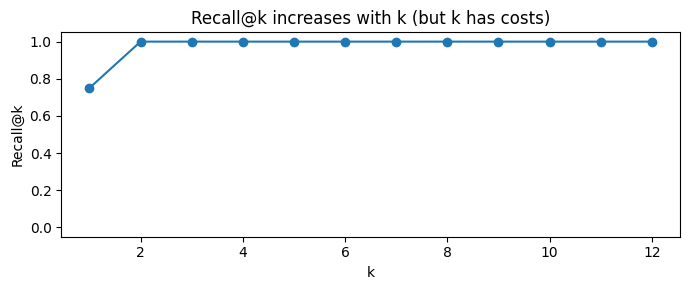

In [14]:
# @title Plot Recall@k curve
ks = list(range(1, 13))
vals = [recall_at_k(eval_set, chunks, X, k=k) for k in ks]

plt.figure(figsize=(7,3))
plt.plot(ks, vals, marker="o")
plt.ylim(-0.05, 1.05)
plt.xlabel("k")
plt.ylabel("Recall@k")
plt.title("Recall@k increases with k (but k has costs)")
plt.tight_layout()
plt.show()


### Reflection
> If Recall@k is high, can hallucination rate still be high?  
> Describe a concrete failure mode.

---

## **Hallucination rate (a practical framing)**
We’ll use a simple operational definition:

1) Break the answer into sentences (claims).
2) Count how many sentences are not supported by context.
3) Hallucination rate = unsupported / total.

In your lab, you’ll compute this more carefully (and report limitations).
For today we’ll use the toy simulator to explore patterns.


In [ ]:
# @title Estimate hallucination rate across the eval set (toy)
def avg_hallucination_rate(eval_set, chunks, X, top_k=8, max_words=180, p_hallucinate=0.25):
    hrs = []
    for ex in eval_set:
        res = search(ex["q"], chunks, X, top_k=top_k)
        ctx, _ = pack_context(res, max_words=max_words)
        ans = toy_answer(ex["q"], ctx, p_hallucinate=p_hallucinate)
        hrs.append(hallucination_rate(ans, ctx))
    return float(np.mean(hrs))

print("Avg hallucination rate (toy):", round(avg_hallucination_rate(eval_set, chunks, X), 2))


---

# Part C — Today's lab preview: sweeps over chunk size and top-*k*
In the lab, you’ll sweep:
- **chunk size** (and a reasonable overlap)
- **top-*k***
and measure:
- **Recall@k**
- **Hallucination rate**

To prepare, we’ll run the sweep in miniature here and plot results.

> Your lab writeup should explain: *why do the curves look the way they do?*  
> The goal isn’t just “bigger is better.”


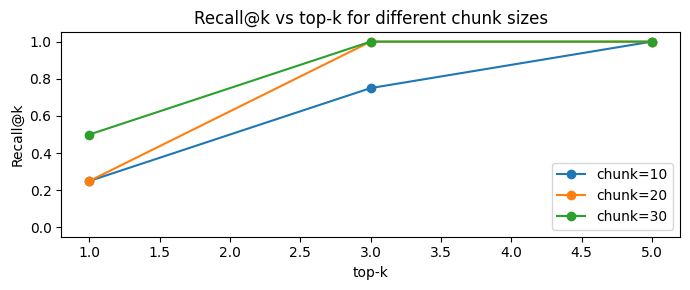

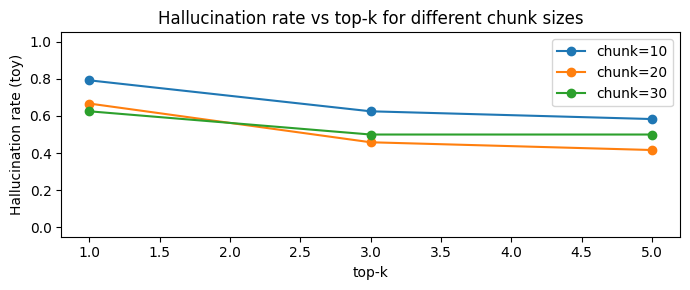

Reminder: hallucination here is simulated; your lab will use a clearer rubric/judge.


In [17]:
# @title Sweep chunk size and top-k, plot Recall@k and hallucination rate (toy)
def build_for_chunking(chunk_size, overlap=None):
    if overlap is None:
        overlap = max(0, chunk_size // 4)
    ch = make_chunks(corpus_docs, chunk_size=chunk_size, overlap=overlap)
    X = build_index(ch)
    return ch, X

chunk_sizes = [10, 20, 30]
topks = [1, 3, 5]

rec_grid = np.zeros((len(chunk_sizes), len(topks)))
hal_grid = np.zeros_like(rec_grid)

for i, cs in enumerate(chunk_sizes):
    ch, Xc = build_for_chunking(cs)
    for j, k in enumerate(topks):
        rec_grid[i, j] = recall_at_k(eval_set, ch, Xc, k=k)
        hal_grid[i, j] = avg_hallucination_rate(eval_set, ch, Xc, top_k=k, max_words=180, p_hallucinate=0.25)

# Plot Recall@k lines
plt.figure(figsize=(7,3))
for i, cs in enumerate(chunk_sizes):
    plt.plot(topks, rec_grid[i], marker="o", label=f"chunk={cs}")
plt.ylim(-0.05, 1.05)
plt.xlabel("top-k")
plt.ylabel("Recall@k")
plt.title("Recall@k vs top-k for different chunk sizes")
plt.legend()
plt.tight_layout()
plt.show()

# Plot hallucination rate lines
plt.figure(figsize=(7,3))
for i, cs in enumerate(chunk_sizes):
    plt.plot(topks, hal_grid[i], marker="o", label=f"chunk={cs}")
plt.ylim(-0.05, 1.05)
plt.xlabel("top-k")
plt.ylabel("Hallucination rate (toy)")
plt.title("Hallucination rate vs top-k for different chunk sizes")
plt.legend()
plt.tight_layout()
plt.show()

print("Reminder: hallucination here is simulated; your lab will use a clearer rubric/judge.")


### Reflection
> Do you see cases where increasing top-*k* increases Recall@k, but hallucination rate does not improve (or gets worse)?  
> Why might that happen in a real system?

---

## **Optional interactive demo (Gradio): “turn the knobs”**
If we have time, we’ll use a tiny app to:
- type a question,
- adjust chunk size + top-*k*,
- inspect retrieved chunks,
- and see the toy hallucination rate.

This is **not** a production tool — it’s a way to build intuition quickly.


In [ ]:
# @title Gradio demo: RAG knob playground (optional)
# If Gradio isn't installed, uncomment the pip line.
# !pip -q install gradio

import gradio as gr

def rag_playground(query, chunk_size, top_k, budget_words, p_hall):
    ch, Xc = build_for_chunking(int(chunk_size))
    res = search(query, ch, Xc, top_k=int(top_k))
    ctx, used = pack_context(res, max_words=int(budget_words))
    ans = toy_answer(query, ctx, p_hallucinate=float(p_hall))
    hr = hallucination_rate(ans, ctx)

    retrieved_preview = "\n".join([f"{s:0.3f} | {c['chunk_id']} | {c['title']}" for s, c in res[:min(8, len(res))]])
    return retrieved_preview, f"(used {used} words)\n\n{ctx[:1200]}", f"{ans}\n\nToy hallucination rate: {hr:.2f}"

demo = gr.Interface(
    fn=rag_playground,
    inputs=[
        gr.Textbox(value="Can interns join the on-call rotation?", label="Query"),
        gr.Slider(20, 120, value=70, step=5, label="Chunk size (words)"),
        gr.Slider(1, 15, value=8, step=1, label="top-k"),
        gr.Slider(80, 400, value=180, step=20, label="Context budget (words)"),
        gr.Slider(0.0, 1.0, value=0.25, step=0.05, label="Hallucination probability (toy)")
    ],
    outputs=[
        gr.Textbox(label="Top retrieved (preview)"),
        gr.Textbox(label="Packed context (preview)"),
        gr.Textbox(label="Answer")
    ],
    title="RAG Playground (toy)",
    description="Turn chunk size and top-k knobs; inspect retrieval, context packing, and a simulated hallucination rate."
)

demo.launch(debug=False, share=False)


In [ ]:
# @title RAG: DSPy version
!pip install -q dspy
import dspy
from dspy.retrievers import Embeddings
lm = dspy.LM("openai/gpt-4o-mini")  # or course-provided default
dspy.configure(lm=lm)

class RAG(dspy.Module):
    def __init__(self, search):
        super().__init__()
        self.search = search
        self.respond = dspy.ChainOfThought("context, question -> response")

    def forward(self, question):
        passages = self.search(question).passages
        context = "\n\n".join([f"- {p}" for p in passages])
        return self.respond(context=context, question=question)

def embed_batch(texts):
    return np.vstack([get_text_embedding(t) for t in texts]).astype("float32")

def build_search(chunks, k):
    corpus = [f"[{c['chunk_id']}] {c['text']}" for c in chunks]  # include ids for evaluation
    return Embeddings(embedder=embedder, corpus=corpus, k=k)

embedder = dspy.Embedder(embed_batch)
search = build_search(chunks, k=3)
rag = RAG(search)

In [ ]:
rag('Can interns join the on-call rotation?')

In [ ]:
dspy.inspect_history()

---

# Wrap-up
- **Recall@k** tells you whether retrieval finds relevant evidence.
- **Hallucination rate** tells you whether answers stay supported by evidence.
- Chunk size and top-*k* change both — sometimes in opposite directions.
- Context limits mean retrieval isn’t the whole story.

---

# Lab: Chunk size × top-*k* sweeps
### What you will do
1) Build a corpus + chunk it in multiple ways (vary chunk size; set overlap sensibly).
2) Retrieve top-*k* chunks for each query.
3) Measure:
   - Recall@k
   - Hallucination rate (with a clear scoring method)
4) Plot and explain tradeoffs.

### What you will submit
- A short writeup with:
  - at least **two plots** (Recall@k and hallucination rate vs knobs),
  - a discussion of **why** the curves look the way they do,
  - and one proposed improvement (reranking, filters, diversity packing, etc.).



---

<details>
<summary><strong>Instructor Notes</strong> (click to expand)</summary>

### Suggested pacing (2 × 50 min)

#### Day 1
- **0–10 min** — Lab review: students share results & tradeoffs
- **10–20 min** — Motivation + “grounding” definition + pipeline diagram
- **20–35 min** — Build the minimal RAG sandbox (chunk → embed → retrieve)
- **35–45 min** — Context packing: demonstrate budget plot
- **45–50 min** — Pair activity: predict how chunk size and top-k affect Recall@k and hallucinations

**Key transition line:**  
“Top-k results are not what the model sees — the context window decides.”

#### Day 2
- **0–10 min** — Recap + why evaluation is tricky
- **10–25 min** — Recall@k: compute and interpret; show curve
- **25–35 min** — Hallucination rate framing; emphasize ‘grounded vs true’
- **35–45 min** — Sweep chunk size × top-k; connect to lab requirements
- **45–50 min** — Introduce lab deliverables; students pick knob ranges + plots

### Discussion prompts
- “Can an answer be true but ungrounded? Why does that matter?”
- “When might top-k make hallucination *worse*?”
- “How would reranking change within-context evidence?”

### Optional extensions (advanced)
- Add diversity packing (max chunks per doc)
- Add metadata filtering (prefer newest policies)
- Compare vector-only vs hybrid retrieval (BM25 + embeddings)
- Add a better groundedness judge (LLM-as-judge + spot-checking)

</details>
